# ***ARYAN KHAN | 17 | 221A036***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
n_states = 5
alpha = 0.01
gamma = 1.0
episodes = 100

In [2]:
def state_features(state):
  feature = np.zeros(n_states)
  if 0 < state < n_states + 1:
    feature[state-1] = 1
  return feature



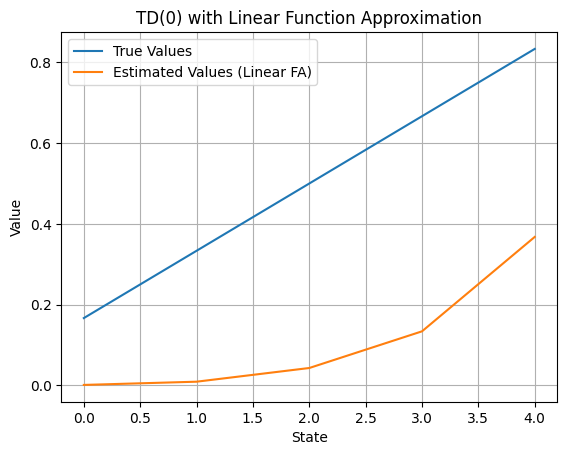

In [3]:
true_values = np.array([1/6, 2/6, 3/6, 4/6, 5/6])

w = np.zeros(n_states)

for ep in range(episodes):
  state = 3
  while True:
    next_state = state + np.random.choice([-1,1])
    #Reward is 1 if we reach the right terminal state (state 6)
    if next_state == 6:
      reward = 1.0
    else:
      reward = 0.0
    #Convert states to features
    x = state_features(state)
    x_next = state_features(next_state)

    v = np.dot(w, x)
    v_next = np.dot(w, x_next) if 0 < next_state < 6 else 0

    td_error = reward + gamma * v_next - v
    w += alpha * td_error * x
    if next_state == 0 or next_state == 6:
      break
    state = next_state

estimated_values = np.dot(np.eye(n_states), w)

plt.plot(true_values, label='True Values')
plt.plot(estimated_values, label="Estimated Values (Linear FA)")
plt.xlabel("State")
plt.ylabel("Value")
plt.legend()
plt.title("TD(0) with Linear Function Approximation")
plt.grid()
plt.show()